In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [77]:
df_train

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,1,1,1,7.0,1,0,2,0,11.611723,112.15875
1,1,0,2,10.0,1,1,1,3,27.078537,68.88056
2,4,1,2,2.0,1,0,1,5,16.643760,39.17320
3,2,2,2,8.0,1,0,1,3,12.937220,80.60793
4,0,0,1,1.0,1,1,1,3,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...
299995,0,1,2,9.0,0,0,2,1,12.730812,129.99749
299996,1,1,0,6.0,0,1,2,1,26.633182,19.85819
299997,3,0,0,9.0,1,1,0,4,11.898250,111.41364
299998,0,2,2,1.0,0,1,2,4,6.175738,115.89080


In [78]:
df_test

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,3,1,2,2.0,0,0,2,3,20.671147
1,2,0,1,7.0,0,1,0,3,13.564105
2,0,0,0,9.0,0,1,1,1,11.809799
3,0,2,0,1.0,1,0,1,3,18.477036
4,0,2,0,2.0,1,1,2,0,9.907953
...,...,...,...,...,...,...,...,...,...
199995,0,0,0,2.0,1,0,1,5,7.383498
199996,2,3,2,9.0,0,1,1,4,6.058394
199997,1,2,2,9.0,0,1,2,3,26.890163
199998,3,2,0,10.0,1,0,2,2,25.769153


In [79]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Brand                 300000 non-null  int64  
 1   Material              300000 non-null  int64  
 2   Size                  300000 non-null  int64  
 3   Compartments          300000 non-null  float64
 4   Laptop Compartment    300000 non-null  int64  
 5   Waterproof            300000 non-null  int64  
 6   Style                 300000 non-null  int64  
 7   Color                 300000 non-null  int64  
 8   Weight Capacity (kg)  300000 non-null  float64
 9   Price                 300000 non-null  float64
dtypes: float64(3), int64(7)
memory usage: 22.9 MB


In [80]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Brand                 200000 non-null  int64  
 1   Material              200000 non-null  int64  
 2   Size                  200000 non-null  int64  
 3   Compartments          200000 non-null  float64
 4   Laptop Compartment    200000 non-null  int64  
 5   Waterproof            200000 non-null  int64  
 6   Style                 200000 non-null  int64  
 7   Color                 200000 non-null  int64  
 8   Weight Capacity (kg)  200000 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 13.7 MB


In [81]:
df_train.isna().sum()

Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64

In [82]:
df_test.isna().sum()

Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
dtype: int64

In [13]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
label = LabelEncoder()

In [23]:
df_train['Brand'].value_counts()

Brand
Adidas          60077
Under Armour    59992
Nike            57336
Puma            56814
Jansport        56076
Name: count, dtype: int64

In [24]:
set(df_test['Brand']).difference(set(df_train['Brand']))

set()

In [26]:
df_train['Brand'] = df_train['Brand'].fillna(df_train['Brand'].mode()[0])
df_test['Brand'] = df_test['Brand'].fillna(df_train['Brand'].mode()[0])

In [29]:
df_train['Brand'] = label.fit_transform(df_train['Brand'])
df_test['Brand'] = label.transform(df_test['Brand'])

In [32]:
df_train['Material'].value_counts()

Material
Polyester    79630
Leather      73416
Nylon        70603
Canvas       68004
Name: count, dtype: int64

In [33]:
df_train['Material'] = df_train['Material'].fillna(df_train['Material'].mode()[0])
df_test['Material'] = df_test['Material'].fillna(df_train['Material'].mode()[0])

In [34]:
df_train['Material'] = label.fit_transform(df_train['Material'])
df_test['Material'] = label.transform(df_test['Material'])

In [41]:
df_train['Size'].value_counts()

Size
Medium    101906
Large      98643
Small      92856
Name: count, dtype: int64

In [42]:
df_train['Size'] = df_train['Size'].fillna(df_train['Size'].mode()[0])
df_test['Size'] = df_test['Size'].fillna(df_test['Size'].mode()[0])

In [43]:
df_train['Size'] =  label.fit_transform(df_train['Size'])
df_test['Size']  = label.transform(df_test['Size'])

In [48]:
df_train['Laptop Compartment'].value_counts()

Laptop Compartment
Yes    148342
No     144214
Name: count, dtype: int64

In [49]:
df_train['Laptop Compartment'] = df_train['Laptop Compartment'].apply(lambda x: np.random.choice(a=['Yes','No'], p = [0.53,0.47]) if pd.isna(x) else x)
df_test['Laptop Compartment'] = df_test['Laptop Compartment'].apply(lambda x: np.random.choice(a=['Yes','No'], p = [0.53,0.47]) if pd.isna(x) else x)

In [50]:
df_train['Laptop Compartment'] =  label.fit_transform(df_train['Laptop Compartment'])
df_test['Laptop Compartment']  = label.transform(df_test['Laptop Compartment'])

In [57]:
df_train['Waterproof'].value_counts()

Waterproof
Yes    148077
No     144873
Name: count, dtype: int64

In [58]:
df_train['Waterproof'] = df_train['Waterproof'].apply(lambda x: np.random.choice(a=['Yes','No'], p = [0.5,0.5]) if pd.isna(x) else x)
df_test['Waterproof'] = df_test['Waterproof'].apply(lambda x: np.random.choice(a=['Yes','No'], p = [0.5,0.5]) if pd.isna(x) else x)

In [59]:
df_train['Waterproof'] =  label.fit_transform(df_train['Waterproof'])
df_test['Waterproof']  = label.transform(df_test['Waterproof'])

In [66]:
df_train['Style'].value_counts()

Style
Messenger    100031
Tote          97438
Backpack      94561
Name: count, dtype: int64

In [67]:
df_train['Style'] = df_train['Style'].fillna(df_train['Style'].mode()[0])
df_test['Style'] = df_test['Style'].fillna(df_test['Style'].mode()[0])

In [68]:
df_train['Style'] =  label.fit_transform(df_train['Style'])
df_test['Style']  = label.transform(df_test['Style'])

In [69]:
df_train['Color'].value_counts()

Color
Pink     51690
Gray     50280
Blue     48097
Red      47219
Green    46386
Black    46378
Name: count, dtype: int64

In [70]:
df_train['Color'] = df_train['Color'].fillna(df_train['Color'].mode()[0])
df_test['Color'] = df_test['Color'].fillna(df_test['Color'].mode()[0])

In [71]:
df_train['Color'] =  label.fit_transform(df_train['Color'])
df_test['Color']  = label.transform(df_test['Color'])

In [76]:
df_train['Weight Capacity (kg)'] = df_train['Weight Capacity (kg)'].fillna(df_train['Weight Capacity (kg)'].median())
df_test['Weight Capacity (kg)'] = df_test['Weight Capacity (kg)'].fillna(df_test['Weight Capacity (kg)'].median())

In [83]:
X_train = df_train.drop('Price', axis=1)
y_train = df_train['Price']
X_test = df_test.copy()

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [85]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
X_train

array([[-0.64631328, -0.52589948,  0.02415106, ...,  1.23810469,
        -1.52159336, -0.92146626],
       [-0.64631328, -1.40950179,  1.27615009, ..., -0.01198839,
         0.25580748,  1.29908617],
       [ 1.42256598, -0.52589948,  1.27615009, ..., -0.01198839,
         1.44074137, -0.19902255],
       ...,
       [ 0.73293956, -1.40950179, -1.22784797, ..., -1.26208147,
         0.84827442, -0.88032993],
       [-1.3359397 ,  0.35770283,  1.27615009, ...,  1.23810469,
         0.84827442, -1.70190428],
       [ 1.42256598, -1.40950179,  1.27615009, ..., -1.26208147,
        -1.52159336,  0.07736253]], shape=(300000, 9))

In [87]:
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [88]:
X_train.shape

(300000, 9)

In [135]:
model = Sequential()
model.add(Dense(units = 4,activation='relu',input_shape = (9, )))
model.add(Dense(units=1, activation='linear'))


C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [136]:
model.compile(optimizer = 'adam' , loss = 'mae')

In [137]:
model.fit(X_train, y_train, validation_split = 0.30, epochs= 35)

Epoch 1/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 48.6894 - val_loss: 34.7775
Epoch 2/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 34.1839 - val_loss: 34.1700
Epoch 3/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 33.8862 - val_loss: 34.0315
Epoch 4/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 33.7973 - val_loss: 33.9705
Epoch 5/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 33.7637 - val_loss: 33.9532
Epoch 6/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 33.7480 - val_loss: 33.9407
Epoch 7/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 33.7407 - val_loss: 33.9348
Epoch 8/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 33.7386 - val_loss: 33.9366
Epoch 9/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 33.7376 - val_loss: 33.9321
Epoch 10/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 33.7366 - val_loss: 33.9340
Epoch 11/35
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 33.7357 - val_loss: 33.93

In [138]:
y_pred = model.predict(X_test)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [139]:
y_pred

array([[80.799644],
       [80.08666 ],
       [78.86388 ],
       ...,
       [81.45788 ],
       [82.63665 ],
       [83.52996 ]], shape=(200000, 1), dtype=float32)

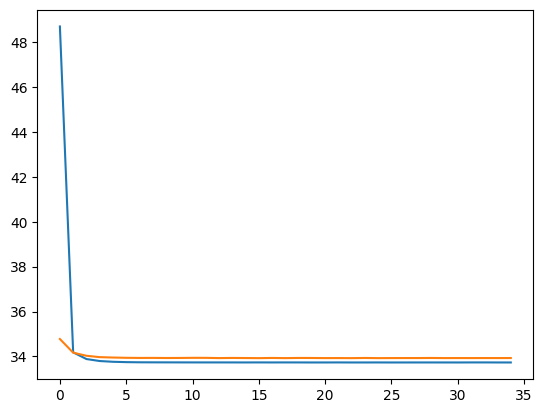

In [140]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [141]:
df_sub = pd.read_csv('sample_submission.csv')

In [142]:
df_sub['Price'] = y_pred

In [143]:
df_sub.to_csv('sub4.csv',index = False, index_label= False)